# Análise de Interrupções de Energia Elétrica no Brasil - 2025

Este notebook conecta ao banco de dados PostgreSQL e gera gráficos para responder aos objetivos do estudo: perfil de interrupções, causas, desempenho de agentes regulados, impacto nos consumidores, correlação entre tipo de interrupção e duração, e indicadores de monitoramento.

In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt 
from sqlalchemy import create_engine
import re
import difflib

load_dotenv()

DB_HOST = os.getenv('DB_HOST', 'localhost')
DB_PORT = os.getenv('DB_PORT', 5432)
DB_NAME = os.getenv('DB_NAME')
DB_USER = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASS')

# Criar URL de conexão com SQLAlchemy
DATABASE_URL = f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(DATABASE_URL)

print('Conexão configurada:')
print(f'  host={DB_HOST} port={DB_PORT} dbname={DB_NAME} user={DB_USER}')

Conexão configurada:
  host=localhost port=5432 dbname=interrupcoes_2025 user=postgres


In [2]:
def carregar_dados_postgres():
    consulta = '''
    SELECT *
    FROM interrupcoes3
    '''
    
    df = pd.read_sql(consulta, engine)
    return df

df = carregar_dados_postgres()
print(f'Linhas carregadas: {len(df)}')
print(df.dtypes)

Linhas carregadas: 9743787
ideconjuntounidadeconsumidora           float64
dscconjuntounidadeconsumidora               str
dscalimentadorsubestacao                    str
dscsubestacaodistribuicao                   str
numordeminterrupcao                         str
dsctipointerrupcao                          str
idemotivointerrupcao                    float64
datiniciointerrupcao             datetime64[us]
datfiminterrupcao                datetime64[us]
dscfatogeradorinterrupcao                   str
numniveltensao                          float64
numunidadeconsumidora                       str
numconsumidorconjunto                       str
numano                                  float64
nomagenteregulado                           str
sigagente                                   str
numcpfcnpj                                  str
dtype: object


In [3]:
# Verificar colunas disponíveis
print('Colunas disponíveis:')
print(df.columns.tolist())
print(f'\nForma do DataFrame: {df.shape}')

Colunas disponíveis:
['ideconjuntounidadeconsumidora', 'dscconjuntounidadeconsumidora', 'dscalimentadorsubestacao', 'dscsubestacaodistribuicao', 'numordeminterrupcao', 'dsctipointerrupcao', 'idemotivointerrupcao', 'datiniciointerrupcao', 'datfiminterrupcao', 'dscfatogeradorinterrupcao', 'numniveltensao', 'numunidadeconsumidora', 'numconsumidorconjunto', 'numano', 'nomagenteregulado', 'sigagente', 'numcpfcnpj']

Forma do DataFrame: (9743787, 17)


In [4]:
# Padronizar nomes de colunas para minúsculas
df.columns = df.columns.str.lower()

# Função para substituir qualquer caractere não-ASCII por 'ï¿½'
def mask_text(s):
    return re.sub(r'[^\x00-\x7F]', 'ï¿½', s) if pd.notna(s) else s

# Converter datas e calcular duração
df['datiniciointerrupcao'] = pd.to_datetime(df['datiniciointerrupcao'], errors='coerce')
df['datfiminterrupcao'] = pd.to_datetime(df['datfiminterrupcao'], errors='coerce')
df['duracao_horas'] = (df['datfiminterrupcao'] - df['datiniciointerrupcao']).dt.total_seconds() / 3600

# Normalizar tipo de interrupção
df['tipo_interrupcao'] = df['dsctipointerrupcao'].fillna('').str.strip()
# versão lower sem acentos removidos (para comparação normal)
df['tipo_interrupcao_norm'] = df['tipo_interrupcao'].str.lower()
# versão com caracteres não-ASCII trocados por 'ï¿½'
df['tipo_interrupcao_masked'] = df['tipo_interrupcao'].astype(str).apply(mask_text).str.lower()

# Distribuidora e fato gerador
df['distribuidora'] = df['nomagenteregulado'].fillna(df.get('sigagente', pd.Series())).fillna('Desconhecido')
df['distribuidora_masked'] = df['distribuidora'].astype(str).apply(mask_text)

df['fator_gerador'] = df['dscfatogeradorinterrupcao'].fillna('Sem informação').str.strip()
df['fator_gerador_masked'] = df['fator_gerador'].astype(str).apply(mask_text)

# Visualizar
df.head(5)

,ideconjuntounidadeconsumidora,dscconjuntounidadeconsumidora,dscalimentadorsubestacao,dscsubestacaodistribuicao,numordeminterrupcao,dsctipointerrupcao,idemotivointerrupcao,datiniciointerrupcao,datfiminterrupcao,dscfatogeradorinterrupcao,...,sigagente,numcpfcnpj,duracao_horas,tipo_interrupcao,tipo_interrupcao_norm,tipo_interrupcao_masked,distribuidora,distribuidora_masked,fator_gerador,fator_gerador_masked
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,...,Nï¿½o Informado,21544060000145,NaN,,,,ASSURUA 2 X ENERGIA S.A,ASSURUA 2 X ENERGIA S.A,Sem informação,Sem informaï¿½ï¿½o
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,...,LUIS ANTONIO RUIVO,27136810817,NaN,,,,LUIS ANTONIO RUIVO,LUIS ANTONIO RUIVO,Sem informação,Sem informaï¿½ï¿½o
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,...,EDMOND CHAKER FARHAT,25593586896,NaN,,,,EDMOND CHAKER FARHAT JUNIOR,EDMOND CHAKER FARHAT JUNIOR,Sem informação,Sem informaï¿½ï¿½o
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,...,EDIO OLIVO,37542699920,NaN,,,,EDIO OLIVO,EDIO OLIVO,Sem informação,Sem informaï¿½ï¿½o
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,...,Nï¿½o Informado,05303481000128,NaN,,,,UNIGEL S/A,UNIGEL S/A,Sem informação,Sem informaï¿½ï¿½o


In [6]:
# --- Contar frequência de cada linha do arquivo fato_interrupcao no DataFrame ---
print(f'Total de linhas no arquivo: {len(masks)}')
print(f'Total de registros no DataFrame: {len(df)}')
print()

# Para cada linha do arquivo, contar quantas vezes aparece em fator_gerador
contagem_por_linha = []
for linha in masks['raw'].unique():
    count = (df['fator_gerador'] == linha).sum()
    contagem_por_linha.append({'fato_gerador': linha, 'frequencia': count})

contagem_df = pd.DataFrame(contagem_por_linha).sort_values('frequencia', ascending=False)

print('=== FREQUÊNCIA DE CADA FATO GERADOR (LINHAS DO ARQUIVO) ===')
print(contagem_df.to_string(index=False))
print()
print(f'MAIS FREQUENTE: {contagem_df.iloc[0]["fato_gerador"]}')
print(f'Frequência: {contagem_df.iloc[0]["frequencia"]:,} ocorrências')
print()

# Criar 3 visualizações
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Gráfico de barras horizontal - Top 15
top_15 = contagem_df.head(15)
ax1 = axes[0, 0]
ax1.barh(range(len(top_15)), top_15['frequencia'].values, color='#1f77b4')
ax1.set_yticks(range(len(top_15)))
ax1.set_yticklabels(top_15['fato_gerador'].values, fontsize=9)
ax1.set_xlabel('Frequência', fontsize=10)
ax1.set_title('Top 15 Fatores Geradores - Barras Horizontais', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# 2. Gráfico de barras vertical - Top 10
top_10 = contagem_df.head(10)
ax2 = axes[0, 1]
bars = ax2.bar(range(len(top_10)), top_10['frequencia'].values, color='#2ca02c')
ax2.set_xticks(range(len(top_10)))
ax2.set_xticklabels(top_10['fato_gerador'].values, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Frequência', fontsize=10)
ax2.set_title('Top 10 Fatores Geradores - Barras Verticais', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=8)
    

# 3. Gráfico de pizza - Top 10 vs Outros
top_10_pizza = contagem_df.head(10).copy()
total_others = contagem_df.iloc[10:]['frequencia'].sum()
pizza_data = pd.concat([top_10_pizza[['fato_gerador', 'frequencia']], 
                         pd.DataFrame({'fato_gerador': ['Outros'], 'frequencia': [total_others]})])

ax3 = axes[1, 0]
colors = plt.cm.Set3(range(len(pizza_data)))
wedges, texts, autotexts = ax3.pie(pizza_data['frequencia'].values, 
                                     labels=pizza_data['fato_gerador'].values,
                                     autopct='%1.1f%%',
                                     startangle=90,
                                     colors=colors,
                                     textprops={'fontsize': 8})
ax3.set_title('Distribuição dos Fatores Geradores (Top 10 + Outros)', fontsize=12, fontweight='bold')


# 4. Tabela com top 20
ax4 = axes[1, 1]
ax4.axis('off')
top_20 = contagem_df.head(20).reset_index(drop=True)
top_20['ranking'] = range(1, len(top_20) + 1)
top_20['percentual'] = (top_20['frequencia'] / top_20['frequencia'].sum() * 100).round(2)
top_20_display = top_20[['ranking', 'fato_gerador', 'frequencia', 'percentual']]
top_20_display.columns = ['Rank', 'Fato Gerador', 'Frequência', '%']

table_data = []
for idx, row in top_20_display.iterrows():
    table_data.append([f"{row['Rank']}", row['Fato Gerador'][:30], f"{row['Frequência']:,}", f"{row['%']:.2f}%"])

table = ax4.table(cellText=table_data, 
                  colLabels=['Rank', 'Fato Gerador', 'Freq.', '%'],
                  cellLoc='left',
                  loc='center',
                  colWidths=[0.08, 0.65, 0.15, 0.12])
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)
ax4.set_title('Top 20 Fatores Geradores - Tabela Detalhada', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()




NameError: name 'masks' is not defined

## 1. Fatos geradores das interrupções não programadas e distribuição por distribuidora

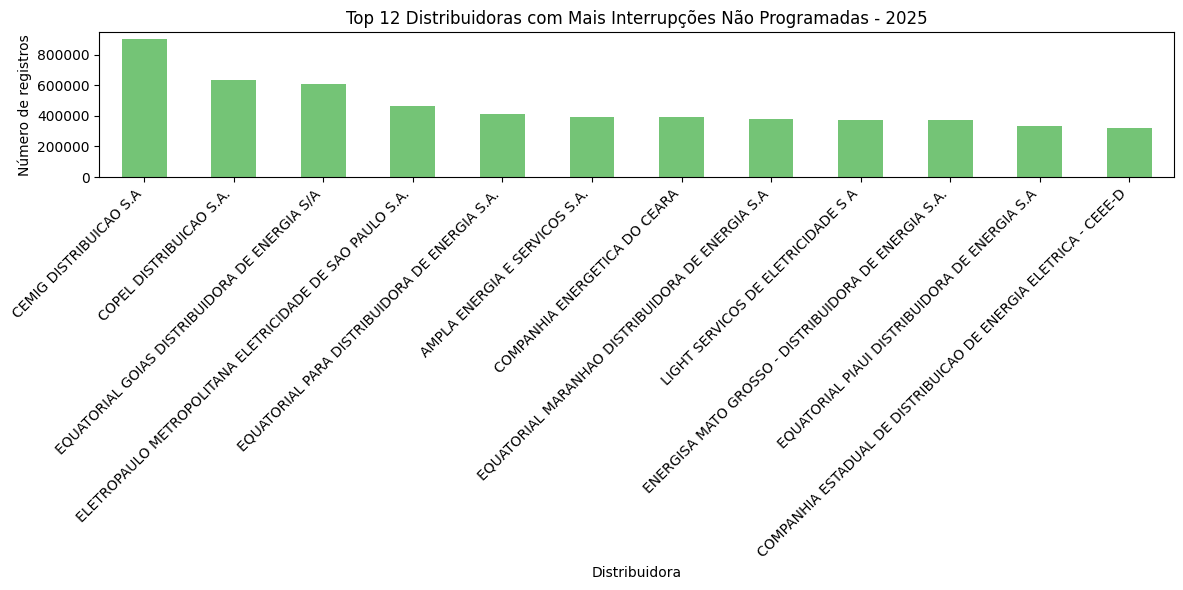

In [ ]:
top_distribuidoras = nao_programadas['distribuidora'].value_counts().head(12)

plt.figure(figsize=(12, 6))
top_distribuidoras.plot(kind='bar', color='#74c476')
plt.title('Top 12 Distribuidoras com Mais Interrupções Não Programadas - 2025')
plt.xlabel('Distribuidora')
plt.ylabel('Número de registros')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Desempenho dos agentes regulados em frequência e duração das interrupções

In [ ]:
# Calcular mês/ano a partir da data de início da interrupção
# e frequência média mensal por distribuidora

df['mes_ano'] = df['datiniciointerrupcao'].dt.to_period('M')

monthly_counts = (
    df.dropna(subset=['mes_ano'])
      .groupby(['distribuidora', 'mes_ano'])
      .agg(registros_mes=('numordeminterrupcao', 'count'))
      .reset_index()
)

monthly_avg = (
    monthly_counts
      .groupby('distribuidora')['registros_mes']
      .mean()
      .reset_index(name='freq_media_mensal')
)

agentes = (
    df.groupby('distribuidora')
      .agg(
          eventos=('numordeminterrupcao', 'nunique'),
          registros=('numordeminterrupcao', 'count'),
          duracao_media=('duracao_horas', 'mean'),
          duracao_mediana=('duracao_horas', 'median')
      )
      .reset_index()
      .merge(monthly_avg, on='distribuidora', how='left')
      .sort_values('registros', ascending=False)
      .head(12)
      .set_index('distribuidora')
)

agentes['freq_media_mensal'] = agentes['freq_media_mensal'].round(1)

agentes

,eventos,registros,duracao_media,duracao_mediana,freq_media_mensal
distribuidora,,,,,
CEMIG DISTRIBUICAO S.A,823126,977857,5.436169,2.883333,81488.1
COPEL DISTRIBUICAO S.A.,684961,685479,4.149387,1.816667,62316.3
EQUATORIAL GOIAS DISTRIBUIDORA DE ENERGIA S/A,609501,609530,5.481261,3.666667,50794.2
ELETROPAULO METROPOLITANA ELETRICIDADE DE SAO PAULO S.A.,441422,474435,6.610912,3.564722,39536.2
EQUATORIAL PARA DISTRIBUIDORA DE ENERGIA S.A.,418392,418392,7.122839,3.733333,34866.0
COMPANHIA ENERGETICA DO CEARA,368933,404848,6.756824,4.278333,33737.3
AMPLA ENERGIA E SERVICOS S.A.,359509,402205,6.452900,3.890833,36564.1
EQUATORIAL MARANHAO DISTRIBUIDORA DE ENERGIA S.A,388986,388986,8.382473,3.929444,32415.5
LIGHT SERVICOS DE ELETRICIDADE S A,386867,386867,6.458085,3.283333,32238.9


<Figure size 1200x600 with 0 Axes>

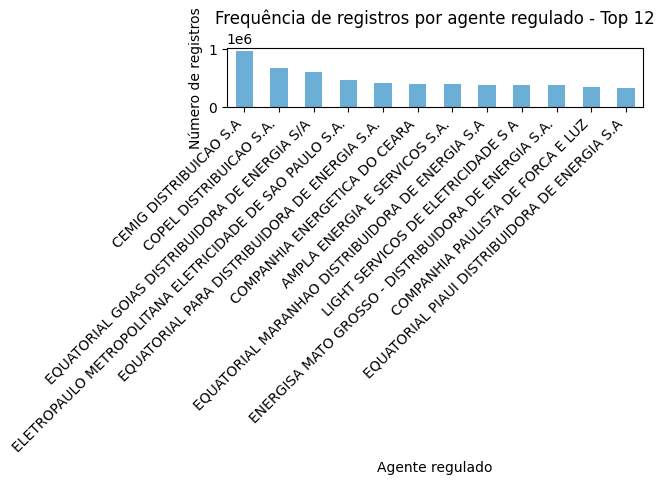

In [ ]:
plt.figure(figsize=(12, 6))
agentes[['registros']].plot(kind='bar', legend=False, color='#6baed6')
plt.title('Frequência de registros por agente regulado - Top 12')
plt.xlabel('Agente regulado')
plt.ylabel('Número de registros')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

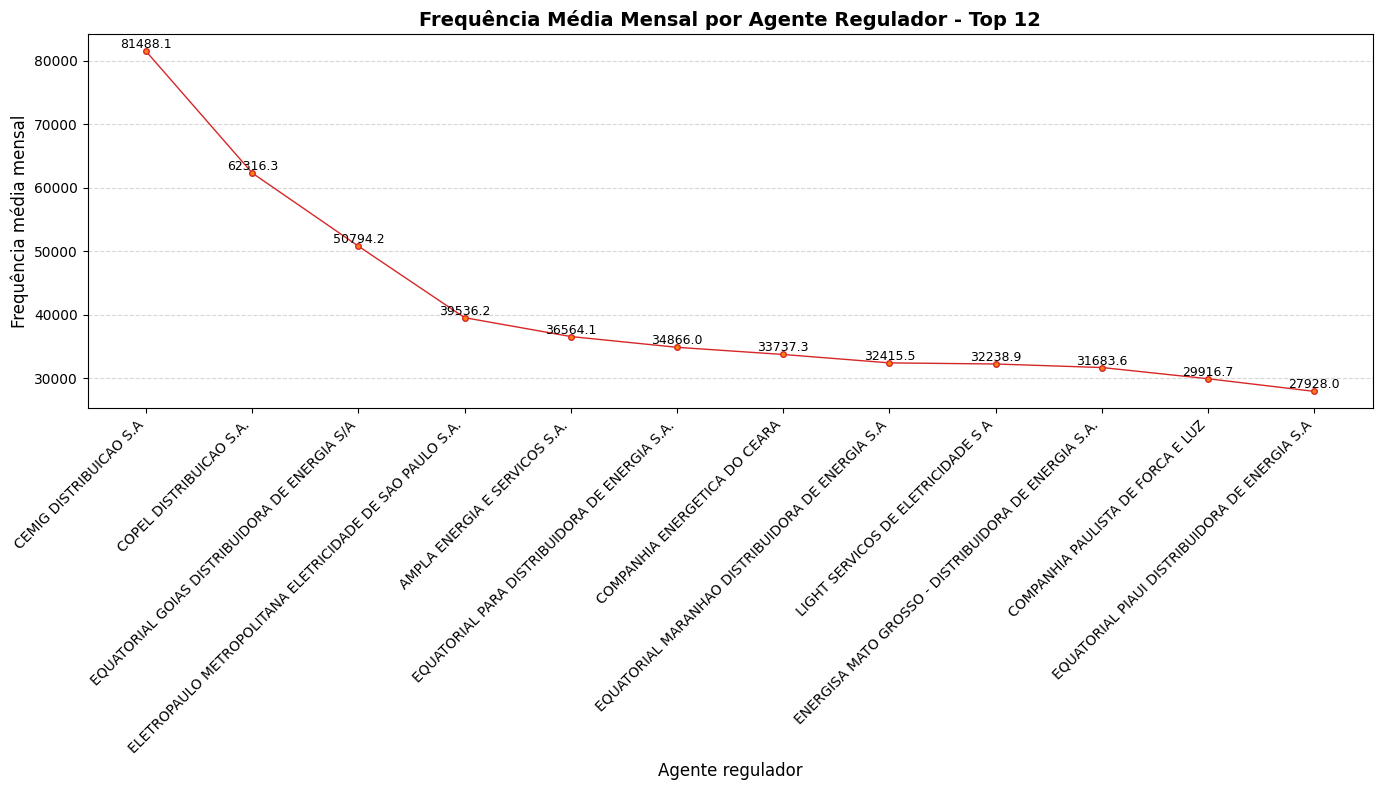

In [ ]:
# Novo estilo de gráfico: frequência média mensal dos principais agentes regulados
plt.figure(figsize=(14, 8))
ax = agentes['freq_media_mensal'].sort_values(ascending=False).plot(
    kind='line',
    marker='o',
    linewidth=1,
    color='#d62728',
    markerfacecolor='#ff7f0e',
    markersize=4
)
ax.set_title('Frequência Média Mensal por Agente Regulador - Top 12', fontsize=14, fontweight='bold')
ax.set_xlabel('Agente regulador', fontsize=12)
ax.set_ylabel('Frequência média mensal', fontsize=12)
ax.set_xticks(range(len(agentes)))
ax.set_xticklabels(agentes.sort_values('freq_media_mensal', ascending=False).index, rotation=45, ha='right', fontsize=10)
for x, y in enumerate(agentes.sort_values('freq_media_mensal', ascending=False)['freq_media_mensal']):
    ax.text(x, y + 0.3, f'{y:.1f}', ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

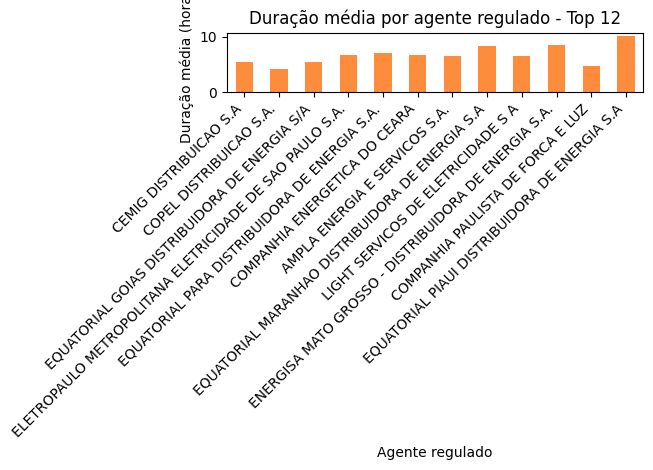

In [ ]:
plt.figure(figsize=(12, 6))
agentes[['duracao_media']].plot(kind='bar', legend=False, color='#fd8d3c')
plt.title('Duração média por agente regulado - Top 12')
plt.xlabel('Agente regulado')
plt.ylabel('Duração média (horas)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Impacto sobre consumidores e eventos de maior magnitude

In [7]:
eventos_unicos = df.groupby('numordeminterrupcao').agg(
    serie_inicio=('datiniciointerrupcao', 'min'),
    serie_fim=('datfiminterrupcao', 'max'),
    duracao_horas=('duracao_horas', 'mean'),
    consumidores_afetados=('numunidadeconsumidora', 'nunique'),
    registros=('numunidadeconsumidora', 'count'),
    distribuidora=('distribuidora', 'first'),
    tipo=('tipo_interrupcao', 'first')
).sort_values('consumidores_afetados', ascending=False).head(12)
eventos_unicos

,serie_inicio,serie_fim,duracao_horas,consumidores_afetados,registros,distribuidora,tipo
numordeminterrupcao,,,,,,,
19307576,2025-10-14 00:31:57,2025-10-14 05:38:49,0.949108,175,256,CEMIG DISTRIBUICAO S.A,Nï¿½o Programada
BA03368994,2025-12-31 02:57:23,2025-12-31 12:44:34,1.278498,162,177,AMPLA ENERGIA E SERVICOS S.A.,Nï¿½o Programada
19338789,2025-10-14 00:31:55,2025-10-14 03:49:00,0.853129,155,227,CEMIG DISTRIBUICAO S.A,Nï¿½o Programada
2025-107635,2025-08-20 14:40:00,2025-08-31 18:37:00,1.155281,140,614,ENERGISA ACRE - DISTRIBUIDORA DE ENERGIA S.A,Nï¿½o Programada
10126472,2025-11-17 12:46:00,2025-11-17 15:36:00,0.510417,135,216,EDP ESPIRITO SANTO DISTRIBUICAO DE ENERGIA S.A.,Nï¿½o Programada
BA03256690,2025-07-10 16:23:00,2025-07-10 16:34:00,0.154088,104,106,AMPLA ENERGIA E SERVICOS S.A.,Nï¿½o Programada
19360834,2025-10-17 09:32:22,2025-10-17 12:53:36,0.888215,97,131,CEMIG DISTRIBUICAO S.A,Nï¿½o Programada
19407525,2025-10-14 00:31:53,2025-10-14 03:38:00,0.855924,96,125,CEMIG DISTRIBUICAO S.A,Nï¿½o Programada
18720736,2025-01-28 19:32:51,2025-01-28 19:40:58,0.081242,96,117,CEMIG DISTRIBUICAO S.A,Nï¿½o Programada


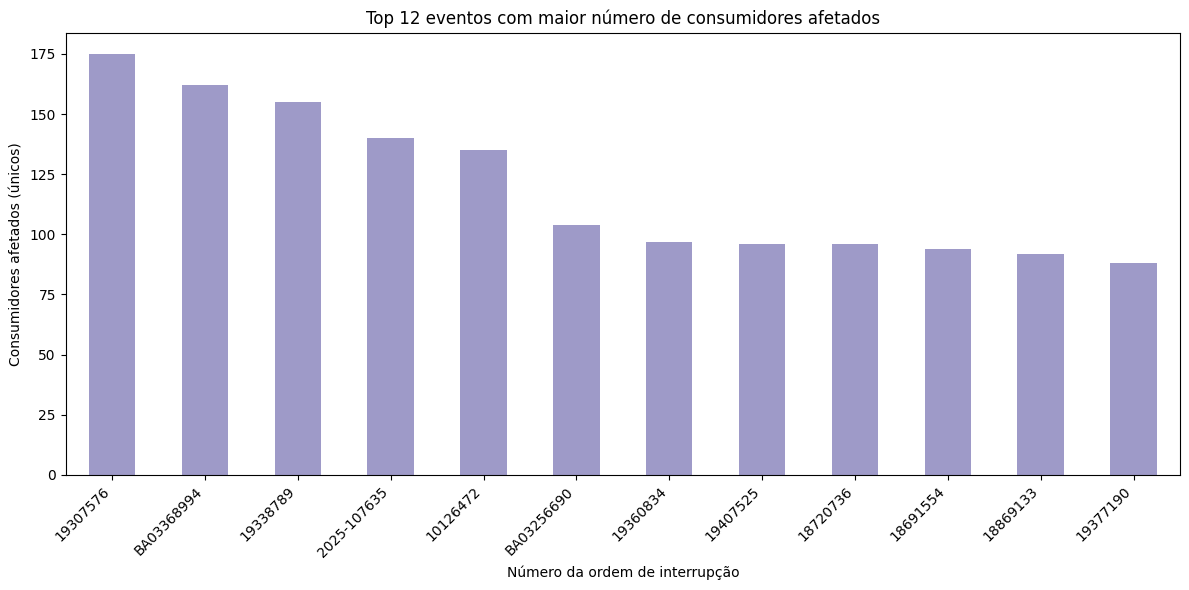

In [8]:
plt.figure(figsize=(12, 6))
eventos_unicos['consumidores_afetados'].plot(kind='bar', color='#9e9ac8')
plt.title('Top 12 eventos com maior número de consumidores afetados')
plt.xlabel('Número da ordem de interrupção')
plt.ylabel('Consumidores afetados (únicos)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Correlação entre tipo de interrupção e duração do evento

In [9]:
duracao_por_tipo = df.groupby('tipo_interrupcao')['duracao_horas'].agg(['count', 'mean', 'median', 'std']).reset_index()
duracao_por_tipo

,tipo_interrupcao,count,mean,median,std
0,,0,NaN,NaN,NaN
1,Nï¿½o Programada,9194331,6.671916,3.491944,9.916633
2,Programada,521041,3.625912,3.166667,4.771275


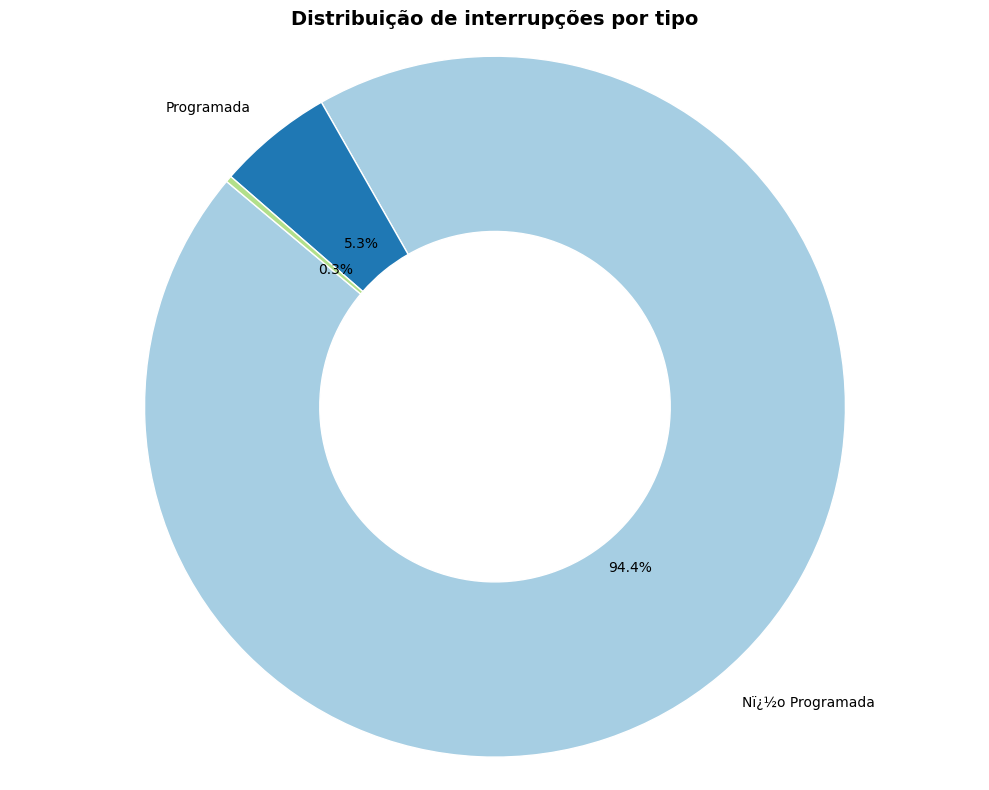

In [11]:
tipo_counts = df['tipo_interrupcao'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
plt.pie(
    tipo_counts.values,
    labels=tipo_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired(range(len(tipo_counts))),
    wedgeprops=dict(width=0.5, edgecolor='white')
)
plt.title('Distribuição de interrupções por tipo', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()


## 5. Indicadores de monitoramento sugeridos

In [13]:
top_fatos = df.loc[df['tipo_interrupcao'] == 'Não Programada', 'fator_gerador'].value_counts()

indicadores = {
    'Total de registros': len(df),
    'Registros não programados': int((df['tipo_interrupcao'] == 'Não Programada').sum()),
    'Participação não programados (%)': round((df['tipo_interrupcao'] == 'Não Programada').mean() * 100, 1),
    'Duração média geral (h)': round(df['duracao_horas'].mean(), 2),
    'Número médio de consumidores afetados por evento': round(eventos_unicos['consumidores_afetados'].mean(), 2),
    'Eventos com maior magnitude (top 5)': ', '.join(map(str, eventos_unicos.head(5).index.tolist())),
    'Fator gerador mais frequente (não programado)': top_fatos.index[0] if len(top_fatos) > 0 else 'N/A'
}
pd.DataFrame(list(indicadores.items()), columns=['Indicador', 'Valor'])


,Indicador,Valor
0,Total de registros,9743787
1,Registros não programados,0
2,Participação não programados (%),0.0
3,Duração média geral (h),6.51
4,Número médio de consumidores afetados por evento,119.5
5,Eventos com maior magnitude (top 5),"19307576, BA03368994, 19338789, 2025-107635, 1..."
6,Fator gerador mais frequente (não programado),N/A
